#Practice Exercises

In [1]:
import pandas as pd
import numpy as np
import random
import string
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets

from IPython.display import display

##Section 1: Python Exercises

###101 Numpy and Plotting

####Problem 1
Generate 10,000 samples from a normal distribution with a mean 0 and standard deviation 1.

In [2]:
np.random.normal(0,1,10000)

array([-0.04454047,  0.79641571, -0.77191222, ...,  1.08962766,
       -0.25815521, -1.1633063 ])

####Problem 2
Creat a list called `mean_list`and set it equal to [0,2,4,6].

In [3]:
mean_list = [0,2,4,6]
mean_list

[0, 2, 4, 6]

####Problem 3
Write a loop that loops through `mean_list`:
- In each loop, generate 10,000 samples from a normal distribution with mean `i`(the value in `mean_list`) and standard deviation 1 For example, loop 1 will generate samples from a normal distribution with mean 0, loop 2 will generate samples from a normal distribution with mean 2, and so on.
- In each loop, also plot a histogram of the samples you generate. Plot the histograms on the same figure (i.e., do not use subplots). Set àlpha`= 0.5 so that the histograms are somewhat transparent.
- Add a legend and axis labels.

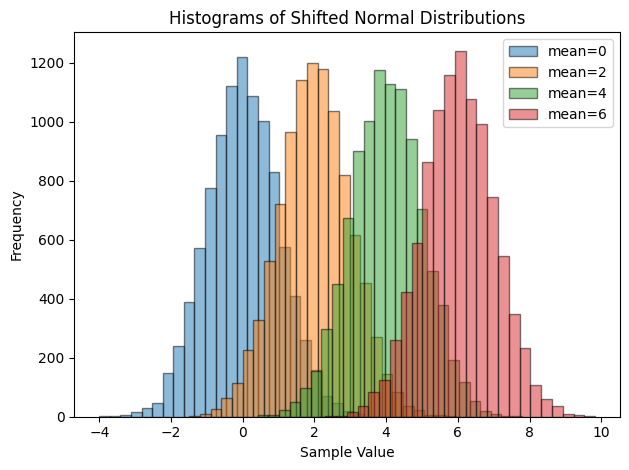

In [4]:
for i in mean_list:
  samples = np.random.normal(i,1,10000)
  plt.hist(
    samples,
    bins=25,
    alpha=0.5, #Transparency
    label=f'mean={i}',
    edgecolor='black'
  )

plt.title('Histograms of Shifted Normal Distributions')
plt.xlabel('Sample Value')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

####Problem 4

Create a variable called `age`and set it equal to 20 equally spaced points between 1 and 100. Create a second variable called `free_time`and set it equal to $(age-50)^2$.

In [5]:
#Creates array of equally spaced points
age = np.linspace(1,100,20,dtype=int)
print(age)
print()

free_time = (age - 50)**2
print(free_time)

[  1   6  11  16  21  27  32  37  42  47  53  58  63  68  73  79  84  89
  94 100]

[2401 1936 1521 1156  841  529  324  169   64    9    9   64  169  324
  529  841 1156 1521 1936 2500]


####Problem 5

Create a plot of `free_time` vs `age`with these additional features:
- Use both markers and a line
- Change your marker shape to a triangle
- Change color of line and markers to your choice
- Change marker size and linewidth so they are easer to see
- Add axis lables

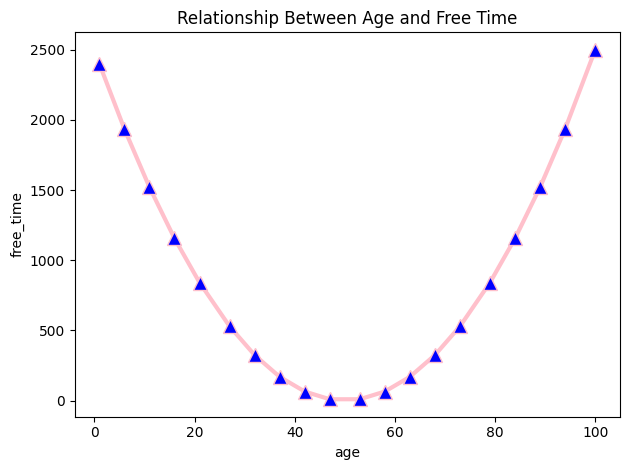

In [6]:
plt.plot(
  age,
  free_time,
  marker='^',
  markersize=10.0,
  linewidth=3.0,
  markerfacecolor='blue',
  color='pink'
)

plt.title('Relationship Between Age and Free Time')
plt.xlabel('age')
plt.ylabel('free_time')

plt.tight_layout()
plt.show()

####**BONUS**
Write a function that takes in a string as its input. This function should return the number of letters and words in the string.

For example:
- string_counter("Hello, my name is Bob.") -> (16, 5)
- string_counter("What's up?") -> (7, 2)
- string_counter(" ") -> (0,0)

```python
string_counter('Hello, my name is Bob.')

string_counter("What's up?")

string_counter(' ')
```

In [7]:
def string_counter(text):
  '''
  This function takes the string as input and returns the number of letters and words in string.
  '''

  letter_count = 0
  for character in text:
    if character.isalpha():        #Checks for upper/lowercase
      letter_count += 1            #Adds 1 to count if character is letter

  # letter_count = sum(char.isalpha() for char in text)   Option 2: One line

  word_count = len(text.split())

  return(letter_count, word_count)

print(string_counter('Hello, my name is Bob.'))
print(string_counter("What's up?"))
print(string_counter(' '))

(16, 5)
(7, 2)
(0, 0)


###102 Game Exercises

####Rock, Paper, Scissors
In this game, the user will be playing Rock, Paper, Scissors against the computer. Your code should request input from the user and it should randomly generate a choice for the computer. It should print out the winner along with a message about how they won (e.g., "The computer won. Scissor cuts paper").

In [8]:
#Three possible moves
choices = ['Rock','Paper','Scissors']
#Dictionary mapping winning move to the move it beats
wins = {
  'Rock':'Scissors',
  'Scissors':'Paper',
  'Paper':'Rock'
}

#Create dropdown
user = widgets.Dropdown(
  options=choices,                        #Options of dropdown
  value='Rock',                           #Initial value filled
  description='Rock, paper or scissors?', #Prompt displayed next to dropdown
  style={'description_width':'initial'},  #Shows entire description
  layout=widgets.Layout(width='250')
)

#Create button
button = widgets.Button(
  description='Shoot',                    #Title on button
  button_style='success'                  #Makes button green
)

#Creates area where results will be printed
output = widgets.Output()

#Create function to play game
def rps(b):
  """
  This function will play Rock, Paper, Scissors everytime the 'Shoot' button(b) clicked
  Submitting the player's choice against the computer.
  """

  with output:
    output.clear_output()                 #Clears previous results

    computer = random.choice(choices)     #Random choice from computer
    player = user.value                   #Move player selected from dropdown

    #Display computer's choice
    print(f'Computer chose: {computer}\n')

    #Determine winner
    if player == computer:
      print("It's a tie!")
    elif wins[player] == computer:
      print(f'You won! {player} beats {computer}.')
    else:
      print(f'You lose! {computer} beats {player}.')

#Connect button to function
button.on_click(rps)                      #Runs rps function when button is clicked

#Display widgets
display(user, button, output)

Dropdown(description='Rock, paper or scissors?', layout=Layout(width='250'), options=('Rock', 'Paper', 'Scisso…

Button(button_style='success', description='Shoot', style=ButtonStyle())

Output()

####MadLibs
 In this game, you will request string input from the user (adjectives, nouns, verbs, etc.) and then you will use that input to generate and print out a MadLibs story. Make sure to format the string input so that it looks nice in your story.

In [9]:
print('Welcome to MadLibs!')
print('Fill in the blanks to create a funny story.\n')

#Gather inputs directly into variables
adjective1 = input('Enter an adjective: ').lower()
noun = input('Enter a noun: ').lower()
verb = input('Enter a verb: ').lower()
adjective2 = input('Enter an adjective: ').lower()
animal = input('Enter an animal: ').lower()
place = input('Enter a place: ').lower()
food = input('Enter a food: ').lower()

#Use variables in story
story = f'''
Today I went to a {adjective1} {place}.
I saw a {animal} that was carring a {noun}.
The animal decided to {verb} because it was feeling {adjective2}.
Afterwards, we shared some delicious {food} together.
It was the best day ever!
'''

#Print story
print('\nYour MadLibs Story:')
print(story)

Welcome to MadLibs!
Fill in the blanks to create a funny story.

Enter an adjective: hairy
Enter a noun: tissue
Enter a verb: sweating
Enter an adjective: big
Enter an animal: llama
Enter a place: lab
Enter a food: cracker

Your MadLibs Story:

Today I went to a hairy lab.
I saw a llama that was carring a tissue.
The animal decided to sweating because it was feeling big.
Afterwards, we shared some delicious cracker together.
It was the best day ever!



####Number Guesser
This is a simple guessing game where the computer will generate a random number between 1 to 10, and the user has to guess it in 5 attempts. Based on the user’s guess, the computer will give a hint if the number is high or low. When the user correctly guesses, print the answer along with the number of attempts.

In [10]:
print('Welcome to the Number Guesser Game!')
print('I picked a number between 1 and 10.')
print('You have 5 attempts to guess it.\n')

#Game settings
computer = np.random.randint(1,11)
max_attempts = 5
attempts = 0

#Create dropdown
user = widgets.Dropdown(
  options=range(1,11),                    #Limits dropdown options to 1-10
  value=1,                                #Sets default choice to 1
  description='Enter your guess: ',       #Prompt next to dropdown
  style={'description_width':'initial'},  #Prevents description from being cut off
  layout=widgets.Layout(width='250px')    #Size of dropdown box
)

#Create button
button = widgets.Button(
  description='Guess',                    #Name on button
  button_style='success'                  #Makes button green
)

#Creates space for output
output = widgets.Output()

#Create Number Guesser game
def num_guess(b):                         #(b) represents the button
  '''
  This function runs the game - Number Guesser.
  The computer will randomly generate a number and the player will guess.
  The computer will provide feedback: too high, too low, or correct.
  After 5 attempts the guessing button will be disabled and then it is
  GAME OVER.
  '''

  global attempts                         #Access to modify attemps outside of function

  with output:
    output.clear_output()                 #Clear output before next game

  attempts += 1                           #Add one to guess count
  guess = user.value                      #Grabs dropdown selection

  print(f'\nAttempt: {attempts} of {max_attempts} | Your guess: {guess}')

  if guess == computer:
    print(f'\nCorrect! The number was {computer}.')
    print(f'You guessed it in {attempts} attemp(s)!')
    button.disabled = True
  elif attempts == max_attempts and guess != computer:
    print(f'\nGAME OVER! The number was {computer}.')
    button.disabled=True
  elif guess < computer:
    print('Too low! Try again.')
  else:
    print('Too high! Try again.')

button.on_click(num_guess)

display(user,button,output)

Welcome to the Number Guesser Game!
I picked a number between 1 and 10.
You have 5 attempts to guess it.



Dropdown(description='Enter your guess: ', layout=Layout(width='250px'), options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 1…

Button(button_style='success', description='Guess', style=ButtonStyle())

Output()

##Section 2: Advanced Python Exercises

###201 Game: Climbing the Steps of the Empire State Building
The objective is to create a Dice game logic, that will decide the odds of reaching Step 60 of the Empire State Building in 100 rolls. Simulate sequence multiple times to calculate the probability using the Dice game logic.



####Rules
For each random step sequence we throw a Die.

1. Step 0 at ground level, is the starting point.
1. If the roll of the Die returns 1 or 2, climb down one step.
1. If the roll of the Die returns 3, 4 or 5, go up one step.
1. If the roll of the Die returns 6, throw the Die again and advance the number of steps equal to that throw.
1. There is a little chance of being clumsy and falling down the Stairs in which case we start again from 0.
1. The value of Steps cannot be negative, the lowest value would always be 0 (which is the starting point).

####**Monte Carlo Simulation** Tips
1. The function `random.seed()` may be used to make your results reproducible.
1. To represent clumsiness of falling down, generate a random number between 0 and 1. If that number is less than .001, set the steps value to Zero as is the rule.
1. You'll want to run the Dice game many times to calculate the probability of reaching step 60 in 100 rolls.
Your Tasks
Write code for the above Dice game.
Estimate the probability of reaching step 60 in 100 rolls.
Create a plot of your random walk results.
Solution

####Solution

#####Task 1: Write code for the above Dice game

In [11]:
#Use random seed to make results reproducible
np.random.seed(36)

simulations = 10000
runs = []

for i in range(simulations):

  #1 Set ground level to step 0 as the starting point
  sequence = [0]

  for x in range(100):

    #Grabs last indice in list before rolling again
    step = sequence[-1]

    #Roll
    dice = np.random.randint(1,7)

    #2a If roll returns 1 or 2
    if dice <= 2:
      #2b Go down one step
      step = max(0,step -1)
    #3a If roll returns 3, 4, 5
    elif dice <=5:
      #3b. Go up one step
      step +=1
    else:
      #4 Roll again and step that amount
      step = step + np.random.randint(1,7)

    #5 Clumsiness
    if np.random.rand() < 0.001:
      #6 Steps cannot be negative
      step = 0

    sequence.append(step)

  runs.append(sequence)

#Convert list to np.array and transpose so each column represents one run
runs_array = np.transpose(np.array(runs))

#####Task 2: Estimate the probability of reaching step60 in 100 rolls

In [12]:
#Select las row (final steps) of simulations
ends = runs_array[-1,:]

probability = np.mean(ends >= 60)
print(f'Estimated probability of reaching step 60: {probability:.2%}')

Estimated probability of reaching step 60: 77.69%


#####Task 3: Create a plot of your random walk results

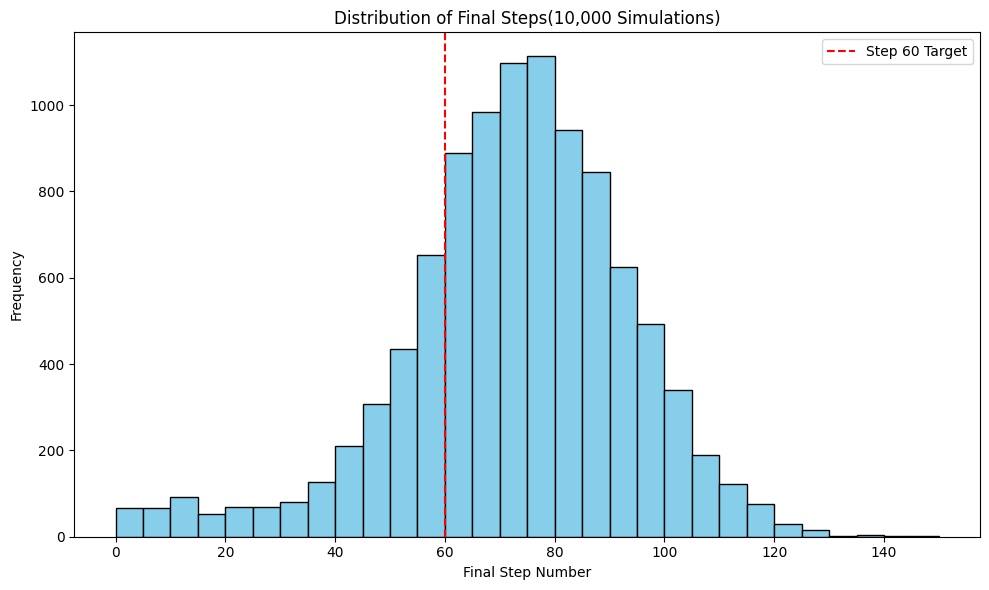

In [13]:
plt.figure(figsize=(10,6))

plt.hist(
  ends,
  bins=30,
  edgecolor='black',
  color='skyblue'
)

plt.title('Distribution of Final Steps(10,000 Simulations)')
plt.xlabel('Final Step Number')
plt.ylabel('Frequency')

plt.axvline(
  x=60,
  color='red',
  linestyle='--',
  label='Step 60 Target'
)

plt.legend()

plt.tight_layout()
plt.show()

###202 Granger's Elf Analysis
Dr. Granger is interested in studying the relationship between the length of house-elves’ ears and aspects of their DNA. This research is part of a larger project attempting to understand why house-elves possess such powerful magic. She has obtained DNA samples and ear measurements from a small group of house-elves to conduct a preliminary analysis (prior to submitting a grant application to the Ministry of Magic) and she would like you to conduct the analysis for her. She has placed the file on the web for you to download, located ==> [here](https://nyu-cds.github.io/courses/data/houseelf_earlength_dna_data.csv) <==.

You might be able to do this analysis by hand in Excel, but counting all of those bases would be a lot of work, and besides, Dr. Granger seems to always get funded, which means that you’ll be doing this again soon with a much larger dataset. So, you decide to write a script so that it will be easy to do the analysis again.

Write a Python script that:

1. Imports the data into a data frame
2. Loops over the rows in the data frame
3. For each row in the dataset, checks to see if the ear length is large (>10 cm) or small (<=10 cm) and determines the GC-content of the DNA sequence (i.e., the percentage of bases that are either G or C)
4. Stores this information in a **new data frame** where the first column has the ID for the individual, the second column contains the string ‘large’ or the string ‘small’ depending on the size of the individuals ears, and the third column contains the GC content of the DNA sequence.
5. Prints the average GC-content for both large-eared elves and small-eared elves to the screen.
6. Exports the table of individual level GC values to a CSV (comma delimited text) file titled grangers_analysis.csv.

**BONUS**: Write functions that perform each of the steps above

[Source for problem](https://nyu-cds.github.io/courses/exercises/Basic-python-2/)

####Solution

In [14]:
#Import into DataFrame
df = pd.read_csv('https://nyu-cds.github.io/courses/data/houseelf_earlength_dna_data.csv')
df.head()

,id,earlength,dnaseq
0,17A,5.1,CCGCATCTTGACTTAACTGACATATTACCATAGATGACTAGCCATG...
1,24P,7.5,GCTATGACTTGCTTAGCTACGTATGAAGGAAGAAACTTTTGTGTAT...
2,09Q,12.2,CCGCCGATTGATACAGGGGACGGTGACGTCGTCATAGATTCGGCAC...
3,65Y,9.9,GCAGGAGAAGTTCTTAACCTTCTCGTAGGACGTCAACCTATTCTTT...
4,19N,10.0,TCTTCATCCTTATCAAAGTTTGGAGTCAATGATCAGGATTATTGCC...


In [15]:
#DEFINE ALL-IN-ONE FUNCTION
def process_elf_data(df, filename='grangers_elf_analysis.csv'):
  '''
  Processes the elf dataset.
  Calculates Ear Size and GC Content.
  Prints averages.
  Exports results to CSV.
  '''

  #Initialize new DataFrame
  results_df = pd.DataFrame()
  results_df['ID'] = df['id']

  #Calculate Ear Size
  results_df['Ear Size'] = df['earlength'].apply(
    lambda ear: 'large' if ear > 10 else 'small'
  )

  #Calculate GC Content
  results_df['GC Content'] = df['dnaseq'].apply(
    lambda dna: (dna.count('G') + dna.count('C')) / len(dna) * 100
  )

  #Print new DataFrame
  print(results_df)
  print()

  #Calculate and print averages
  averages = results_df.groupby('Ear Size')['GC Content'].mean()
  print('Average GC Content')
  print('------------------')
  for size, avg in averages.items():
    print(f'{size.capitalize()} Ears: {avg:.2f}%')

  #Export to CSV
  results_df.to_csv(filename, index=False)
  print(f"\nResults exported to '{filename}'")

  return results_df


#EXECUTE
final_df = process_elf_data(df)

    ID Ear Size  GC Content
0  17A    small        41.0
1  24P    small        39.0
2  09Q    large        57.0
3  65Y    small        40.0
4  19N    small        36.0
5  92K    large        62.0
6  33W    small        52.0
7  98C    large        63.0
8  75G    small        47.0
9  88Q    large        52.0

Average GC Content
------------------
Large Ears: 58.50%
Small Ears: 42.50%

Results exported to 'grangers_elf_analysis.csv'


###203 Tools: Interactive Functions

####Passowrd Generator

Create a function that takes the length of the password and generates a random password of the same length with at least one character, one number and one symbol. Example: ```password(5) -> 'arg5!'```

In [16]:
def password(length):

  characters = string.ascii_letters
  numbers = string.digits
  symbols = string.punctuation

  #Required characters
  password = [
    random.choice(characters),
    random.choice(numbers),
    random.choice(symbols)
  ]

  #Fill in remaining characters
  all = characters + numbers + symbols

  for i in range(length - 3):
    password.append(random.choice(all))

  #Shuffle password
  random.shuffle(password)

  return ''.join(password)

#User input
length = input('Enter password length (6-15): ')

#Validate input
if length.isdigit():

  length = int(length)

  if 6 <= length <= 15:
    print(f'Your password is {password(length)}')

  elif length > 30:
    print('Password is too long. Maximum length is 30.')

  elif length < 6:
    print('Password is too short. Minimum length is 6.')

else:
  print('Invalid input. Try again.')

Enter password length (6-15): 9
Your password is *O9ca+KX6


####Email Slicer

Create a function that takes as input an email address and returns a string that contains two items - the person's username and the domain name. Example: ```email_slicer('nevin@cnm.edu') -> ('nevin', 'cnm.edu')```

In [17]:
def email_slicer(email):

  #Check if email is valid
  if '@' not in email or '.' not in email:
    return 'Invalid email. Enter correct email address.'

  #Split
  username, domain = email.split('@')

  #Check for missing username or domain
  if username == '' or domain == '':
    return 'Invalid email. Enter correct email address.'

  return username, domain

#User input
email = input('Enter your email: ')
print(email_slicer(email))

Enter your email: stephanie465337@gmail.com
('stephanie465337', 'gmail.com')


####Acronym Creator

Create a function that takes as input a string and returns an acronym that contains the first letter of each word in that string. Example: ```acronym_creator("My name is Nevin") -> "MNIN"```

In [18]:
def acronym_creator(sentence):

  words = sentence.split()
  acronym = ''

  for word in words:
    acronym += word[0].upper()

  return acronym

sentence = input('Enter a phrase: ')
print(acronym_creator(sentence))

Enter a phrase: Whatever will be will be
WWBWB


####Dice Roller

Create a function that takes as input a positive integer `n`. This function should simulate the rolling of a `n`-sided die 1000 times. It should create a seaborn countplot of the distribution of die rolls.

Enter number of sides on die: 6


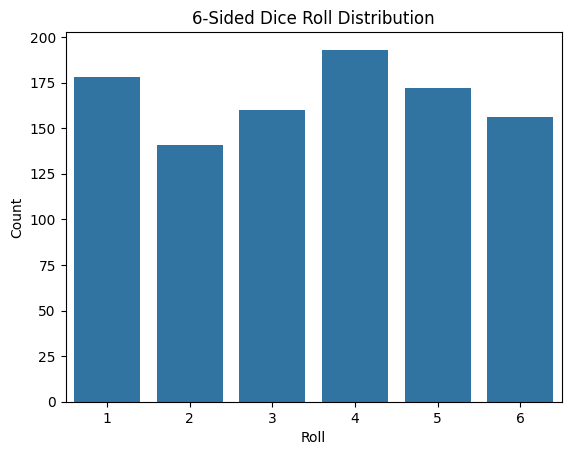

In [19]:
def dice_roller(n):

  rolls = []

  for i in range(1000):
    rolls.append(random.randint(1,n))

  sns.countplot(x=rolls)

  plt.xlabel('Roll')
  plt.ylabel('Count')
  plt.title(f'{n}-Sided Dice Roll Distribution')

  plt.show()

sides = int(input('Enter number of sides on die: '))
dice_roller(sides)

#create caveate that limits input to an integer else print invalid input

####Max of Three

Create a function that takes as input three floats and returns the largest of the three. Do this without using the Python max() function! Example: ```max_of_three(5,10,3) -> 10```


In [20]:
def max_three(a, b, c):

  if a >= b and a >= c:
    return a
  elif b >= a and b >= c:
    return b
  else:
    return c


#User input
try:
    a = float(input("Enter first number: "))
    b = float(input("Enter second number: "))
    c = float(input("Enter third number: "))

    #Call function
    largest = max_three(a, b, c)

    print(f"The largest number is: {largest}")

except ValueError:
    print("Invalid input. Please enter numbers only.")

Enter first number: 9
Enter second number: 3
Enter third number: 7
The largest number is: 9.0


####Age Calculator

Create a function that takes as input someone's age in years and prints their age in days, hours and minutes. Example: ```age_calculator(33) -> "You are 12045 days old. You are 289080 hours old. You are 12592800 minutes old."```

In [21]:
def age_calculator(age):

  days = age*365
  hours = days*24
  minutes = hours*60

  print(f'You are {days} days, {hours} hours and {minutes} minutes old.')

#User input
try:
  age = int(input('Enter age: '))

  if age > 0:
    age_calculator(age)
  else:
    print('Invalid input. Age must be greater than 0.')

except ValueError:
  print('Invalid input. Please enter a whole number.')

Enter age: 33
You are 12045 days, 289080 hours and 17344800 minutes old.


##Section 3: Data Visualization & Exploratory Analysis

###301 Plotting

For this exercise, you will do the following

1. Read in data from AWS - [company_sales_data.csv]( https://ddc-datascience.s3.amazonaws.com/company_sales_data.csv )
1. Create a plot of data for each:
  - [matplotlib](https://matplotlib.org/stable/gallery/index.html)
  - [seaborn](https://seaborn.pydata.org/examples/index.html)
  - [plotly](https://plotly.com/python/plotly-express/)
3. Remember to:
- Add axis labels
- Add legend (if necessary)
- Make sure colors are easy to differentiate
- Make sure font is large enough to easily read

Hint: You may need to do some data restructuring/manipulation to create certain plots.

The pandas `.melt()` and `.groupby()` methods may be helpful.

Reference: [Reshaping Tables With Pandas]( https://medium.com/towards-data-science/reshaping-data-with-pandas-ecff92572488 )

In [22]:
df = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/company_sales_data.csv')

####Matplotlib

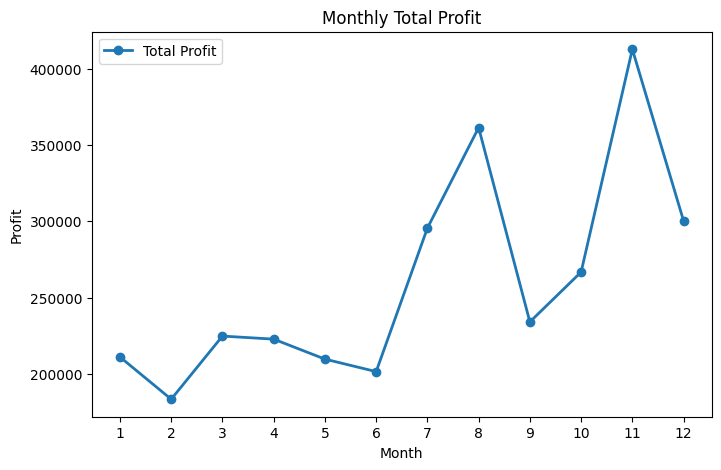

In [23]:
plt.figure(figsize=(8,5))

plt.plot(
  df['month_number'],
  df['total_profit'],
  marker='o',
  linewidth=2,
  label='Total Profit'
)

plt.title('Monthly Total Profit')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(df['month_number'])
plt.legend()

plt.show()

####Seaborn

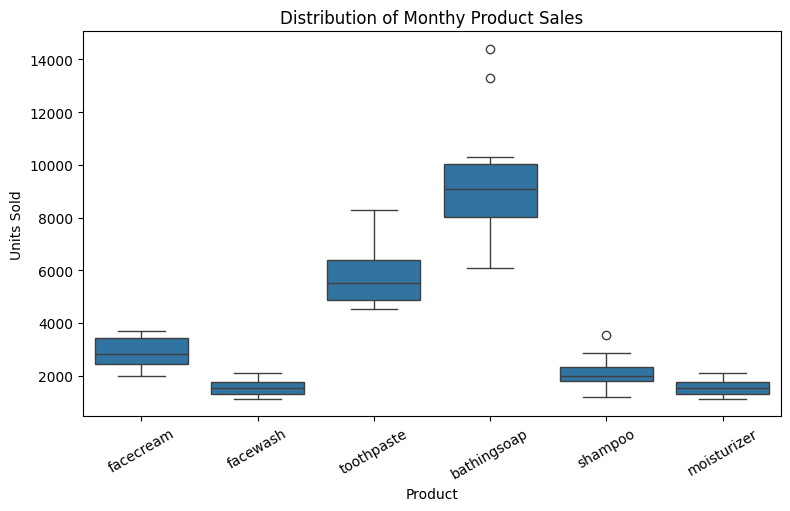

In [24]:
sales_long = df.melt(
  id_vars = 'month_number',
  value_vars = [
    'facecream',
    'facewash',
    'toothpaste',
    'bathingsoap',
    'shampoo',
    'moisturizer'
  ],
  var_name = 'Product',
  value_name = 'Sales'
)

plt.figure(figsize=(9,5))

sns.boxplot(
  data = sales_long,
  x = 'Product',
  y = 'Sales'
)

plt.title('Distribution of Monthy Product Sales')
plt.xlabel('Product')
plt.ylabel('Units Sold')

plt.xticks(rotation = 30)

plt.show()

####Plotly

In [25]:
fig = px.line(
  df,
  x = 'month_number',
  y = 'total_profit',
  title = 'Monthly Total Profit',
  markers = True,
  labels = {
    'month_number':'Month',
    'total_profit':'Total Profit'
  }
)

fig.update_traces(hovertemplate = '<b>Month %{x}</b><br>Total Profit: %{y}<extra></extra>')

fig.update_layout(
  xaxis = dict(rangeslider = dict(visible=True)),
  font = dict(size = 14),
  width = 900,
  height = 600
)

fig.show()

###302 Fires



####Activity 1


Assign AWS [Brazilian-fire-dataset.csv]( https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv ) to variable `df_ffire`

In [26]:
df_ffire = pd.read_csv('https://ddc-datascience.s3.amazonaws.com/Brazilian-fire-dataset.csv')

Display top 10 rows of DataFrame

In [27]:
df_ffire.head(10)

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.0,1/01/1998
1,1999,Acre,January,0.0,1/01/1999
2,2000,Acre,January,0.0,1/01/2000
3,2001,Acre,January,0.0,1/01/2001
4,2002,Acre,January,0.0,1/01/2002
5,2003,Acre,January,10.0,1/01/2003
6,2004,Acre,January,0.0,1/01/2004
7,2005,Acre,January,12.0,1/01/2005
8,2006,Acre,January,4.0,1/01/2006
9,2007,Acre,January,0.0,1/01/2007


Generate summary statistics

In [28]:
df_ffire.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Year,6454.0,2007.461729,5.746654,1998.0,2002.0,2007.0,2012.0,2017.0
Number of Fires,6454.0,108.293163,190.812242,0.0,3.0,24.0,113.0,998.0


#####Answer

What is the maximum number of fires reported on any given day?

In [29]:
max = df_ffire['Number of Fires'].max()

print(f'There are {max:.0f} fires reported on any given day.')

There are 998 fires reported on any given day.


In the dataset, what is the total number of states for which the fire incidents have been reported?

In [30]:
total = df_ffire['State'].nunique()

print(f'{total} states had fire incidents that were reported.')

27 states had fire incidents that were reported.


####Activity 2



Change `Date Reported`column to a datetime object

In [31]:
df_ffire['Date Reported'] = pd.to_datetime(df_ffire['Date Reported'])
print(df_ffire['Date Reported'].dtype)

datetime64[ns]


Filter `df_ffire` to only keep rows  in Acre, Bahia or Mato Grosso states and save as `df_ffire_filt`

In [32]:
df_ffire_filt = df_ffire[
  df_ffire['State'].isin(['Acre', 'Bahia', 'Mato Grosso'])
]

df_ffire_filt.head()

,Year,State,Month,Number of Fires,Date Reported
0,1998,Acre,January,0.0,1998-01-01
1,1999,Acre,January,0.0,1999-01-01
2,2000,Acre,January,0.0,2000-01-01
3,2001,Acre,January,0.0,2001-01-01
4,2002,Acre,January,0.0,2002-01-01


Create a seaborn line plot of `df_ffire_filt` with the `Date Reported` on the x-axis, the `Number of Fires` on the y-axis and the `State` as the hue.

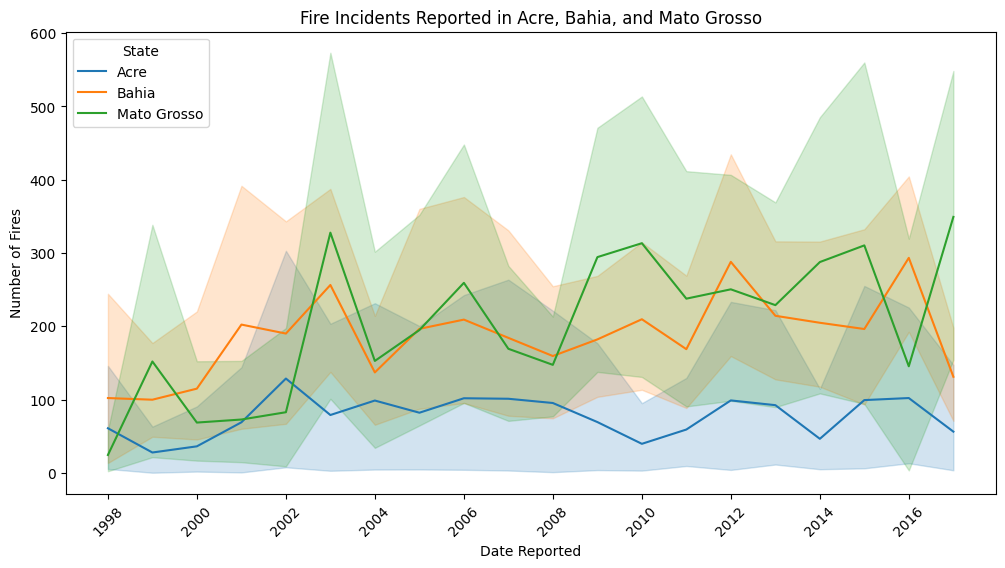

In [33]:
plt.figure(figsize = (12,6))

sns.lineplot(
  data = df_ffire_filt,
  x = 'Date Reported',
  y = 'Number of Fires',
  hue = 'State'
)

plt.title('Fire Incidents Reported in Acre, Bahia, and Mato Grosso')
plt.xlabel('Date Reported')
plt.ylabel('Number of Fires')
plt.legend(title = 'State')

plt.xticks(rotation = 45)

plt.show()

####Activity 3

Create boolean filter for rows with max fires

In [34]:
max_filter = df_ffire['Number of Fires'] == max

Use filter to retrieve record

In [35]:
max_fire = df_ffire[max_filter]
max_fire

,Year,State,Month,Number of Fires,Date Reported
888,2008,Amazonas,September,998.0,2008-01-01


#####Answer

Which state has recorded the maximum number of fires on any given day (not the total sum), and in which month did it occur?

In [36]:
state = max_fire['State'].values[0]
month = max_fire['Date Reported'].dt.month.values[0]

print(f'In {month} the state with the maximum number of fires was {state}.')

In 1 the state with the maximum number of fires was Amazonas.


#### Activity 4

Calculate total fires for each state and save to DataFrame `df_group_states`

In [37]:
df_group_states = pd.DataFrame(df_ffire.groupby('State')['Number of Fires'].sum())

Print Summary Statistics for `df_group_states`

In [38]:
df_group_states.describe()

,Number of Fires
count,27.000000
mean,25886.076778
std,14260.072004
min,3237.000000
25%,15625.515000
50%,24498.000000
75%,37585.389000
max,51121.198000


#####Answer



What is the minimum and maximum number of total fires records?


In [39]:
max = df_group_states['Number of Fires'].max()
min = df_group_states['Number of Fires'].min()

print(f'Maximum total fires: {max:.0f}.')
print(f'Minimum total fires: {min:.0f}.')

Maximum total fires: 51121.
Minimum total fires: 3237.


Which state has recorded the minimum number of total fires, and which state has recorded the maximum number of total fires?

Use pandas methods `.idxmax()` and `.idxmin()` that return indices corresponding to max/min values

In [40]:
min_state_idx = df_group_states['Number of Fires'].idxmin()
max_state_idx = df_group_states['Number of Fires'].idxmax()

print(f'The State with minimum total fires: {min_state_idx}')
print(f'The State with maximum total fires: {max_state_idx}')

The State with minimum total fires: Sergipe
The State with maximum total fires: São Paulo


####Activity 5



Reset index of `df_group_states`  

Hint: use `.reset_index()`

In [41]:
df_group_states = df_group_states.reset_index()

Arrange DataFrame in descending order by "Number of Fires"


In [42]:
df_group_states = df_group_states.sort_values(by='Number of Fires', ascending=False)

Create `sns.barplot` with Number of Fires on y-axis and State on x-axis, rotate so they are easier to read



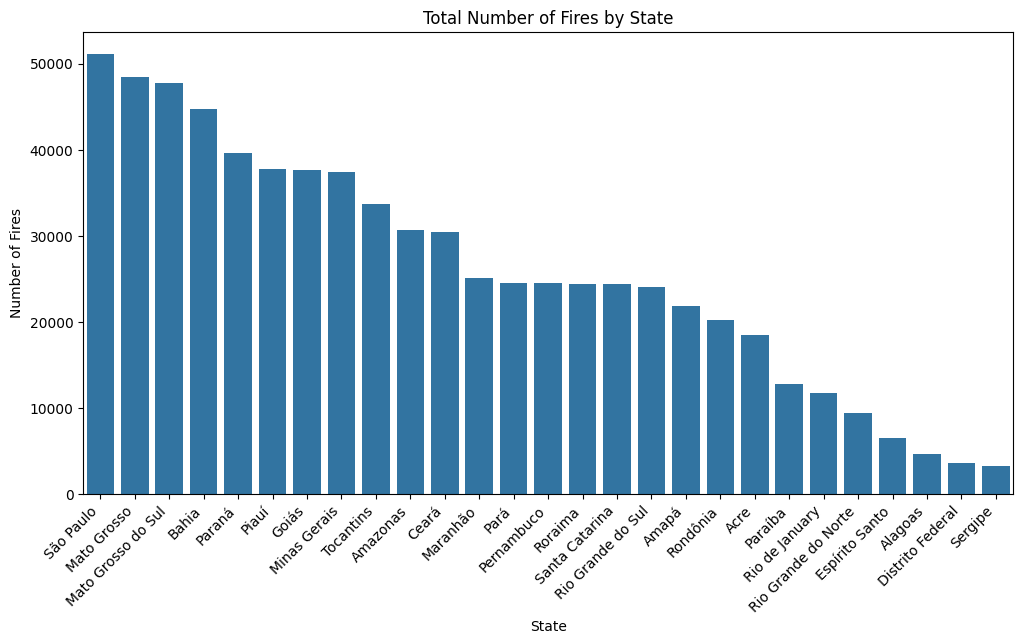

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(data = df_group_states, x = 'State', y = 'Number of Fires')

plt.xticks(rotation=45, ha = 'right')
plt.title('Total Number of Fires by State')

plt.show()